In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from loguru import logger
import sys

In [3]:
logger.remove()
logger.add(sys.stderr, level="INFO")

1

In [4]:
from evaluation_utils import TaxonomyEvaluator
import pandas as pd
import numpy as np

In [6]:
folder = "results"
ground_truth_folder = "data"
approaches = ["greedy", "mv", "abscon"]
llms = ["gpt-4o-mini", "gpt-4o", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct", "qwq-32b"]

dataset = "wordnet"
num_generation = 10

In [7]:
results = []

for approach in approaches:
    ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"

    result = {}
    result["approach"] = approach
    for llm in llms:
        folder_path = f"{folder}/{llm}"
        if approach == "greedy":
            evaluator = TaxonomyEvaluator(
                folder_path,
                dataset,
                ground_truth_path,
                num_generation,
                evaluate_greedy=True,
            )
            df = pd.read_csv(f"{folder_path}/{dataset}/results_{approach}.csv")
            metrics = evaluator.evaluate_abstraction(
                num_generation, concretization_method="mv", dataset=dataset
            )
        else:
            evaluator = TaxonomyEvaluator(
                folder_path, dataset, ground_truth_path, num_generation
            )
            df = pd.read_csv(
                f"{folder_path}/{dataset}/results_{approach}_{num_generation}.csv"
            )
            metrics = evaluator.evaluate_taxonomies(df, dataset)
        

        for metric_name in ["precision", "recall", "f1", "consistency"]:
            result[f"{metric_name}_{llm}"] = metrics[metric_name]
    results.append(result)

In [9]:
results_df = pd.DataFrame(results)
results_df[results_df.select_dtypes(include=['number']).columns] *= 100
# results_df = results_df[["approach", "precision", "recall", "f1", "consistency"]]
# results_df.columns = ["approach", "P", "R", "F1", "Con"]
print(results_df.round(2).to_markdown(index=False))

| approach   |   precision_gpt-4o-mini |   recall_gpt-4o-mini |   f1_gpt-4o-mini |   consistency_gpt-4o-mini |   precision_gpt-4o |   recall_gpt-4o |   f1_gpt-4o |   consistency_gpt-4o |   precision_Meta-Llama-3.1-8B-Instruct |   recall_Meta-Llama-3.1-8B-Instruct |   f1_Meta-Llama-3.1-8B-Instruct |   consistency_Meta-Llama-3.1-8B-Instruct |   precision_Meta-Llama-3.1-70B-Instruct |   recall_Meta-Llama-3.1-70B-Instruct |   f1_Meta-Llama-3.1-70B-Instruct |   consistency_Meta-Llama-3.1-70B-Instruct |   precision_qwq-32b |   recall_qwq-32b |   f1_qwq-32b |   consistency_qwq-32b |
|:-----------|------------------------:|---------------------:|-----------------:|--------------------------:|-------------------:|----------------:|------------:|---------------------:|---------------------------------------:|------------------------------------:|--------------------------------:|-----------------------------------------:|----------------------------------------:|---------------------------------

In [11]:
results_df_index = results_df.set_index("approach", inplace=False)

In [12]:
diff = results_df_index.loc["abscon", :] - results_df_index.loc["greedy", :]
recall_diff = [value for key, value in diff.items() if "recall" in key]
print(f"Min improvement: {min(recall_diff)}, max improvement: {max(recall_diff)}, average improvement: {np.mean(recall_diff)}")

Min improvement: 3.8687533822982942, max improvement: 14.438727683033889, average improvement: 7.518358774799662


In [13]:
f1_diff = [value for key, value in diff.items() if "f1" in key]
print(f"Min improvement: {min(f1_diff)}, max improvement: {max(f1_diff)}, average improvement: {np.mean(f1_diff)}")

Min improvement: 2.532939376487704, max improvement: 12.078915382788594, average improvement: 5.616145825736822


## Plots

In [8]:
from tqdm.notebook import tqdm

In [9]:
folder = "results"
ground_truth_folder = "data"
approaches = ["mv", "greedy", "abscon"]
llms = ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"] # ["Meta-Llama-3.1-70B-Instruct"]

dataset = "wordnet"
num_generations = range(1, 21)
metrics = ["f1", "consistency"]

In [13]:
def get_result(ground_truth_folder, dataset, llms, num_generation, approaches, folder):
    ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"
    result = {}
    for approach in approaches:
        result[approach] = {}
        for llm in llms:
            folder_path = f"{folder}/{llm}"
            if approach == "greedy":
                evaluator = TaxonomyEvaluator(
                    folder_path,
                    dataset,
                    ground_truth_path,
                    num_generation,
                    evaluate_greedy=True,
                )
                metrics = evaluator.evaluate_abstraction(
                    num_generation, concretization_method="mv", dataset=dataset
                )
            else:
                evaluator = TaxonomyEvaluator(
                    folder_path, dataset, ground_truth_path, num_generation
                )
                df = pd.read_csv(
                    f"{folder_path}/{dataset}/results_{approach}_{num_generation}.csv"
                )
                metrics = evaluator.evaluate_taxonomies(df, dataset)
            result[approach][llm] = metrics
    
    return result

In [11]:
results = []

for num_generation in tqdm(num_generations):
    result = get_result(ground_truth_folder, dataset, llms, num_generation, approaches, folder)

    results.append(result)

  0%|          | 0/20 [00:00<?, ?it/s]

In [17]:
ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"
for i in tqdm(range(len(results))):
    results[i]["max"] = {}
    results[i]["median"] = {}
    for llm in llms:
        folder_path = f"{folder}/{llm}"
        evaluator = TaxonomyEvaluator(
            folder_path,
            dataset,
            ground_truth_path,
            num_generations=len(list(num_generations)),
        )

        results[i]["max"][llm] = evaluator.evaluate_individual(i + 1, dataset, aggregator=max)
        results[i]["median"][llm] = evaluator.evaluate_individual(i + 1, dataset, aggregator=np.median)

  0%|          | 0/20 [00:00<?, ?it/s]

[[False, False, True, True, True, False, True, True, True, False, False, True, True, False, True, True, False, False, False, True, True, True, False, True, True, True, False, True, True, True, False, True, True, True, True, True, False, False, True, True, False, True, True, False, False, True, False, False, True, True, False, True, True, True, False, True, False, True, True, True, True, True, False, True, False, True, True, True, False, True, True, True, False, False, True, False, False, False, False, True, True, False, True, False, False, False, False, True, False, True, True, False, True, True, False, True, True, False, True, True]]
[[False, False, True, True, True, False, True, True, True, False, False, True, True, False, True, True, False, False, False, True, True, True, False, True, True, True, False, True, True, True, False, True, True, True, True, True, False, False, True, True, False, True, True, False, False, True, False, False, True, True, False, True, True, True, False, True

In [18]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib
plt.style.use(['science', "ieee"])

# models = ["llama_8b", "llama_70b", "gpt_4o_mini", "gpt_4o"]
models = ["Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]
model_names = ["Llama3.1 70b"]
metrics = ["f1", "consistency"]
approaches = ["mv", "abscon", "max", "median", "greedy"]
approach_names = ["MV", "AbsCon", "Best", "Median", "Direct"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] , [71, 133, 90],  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

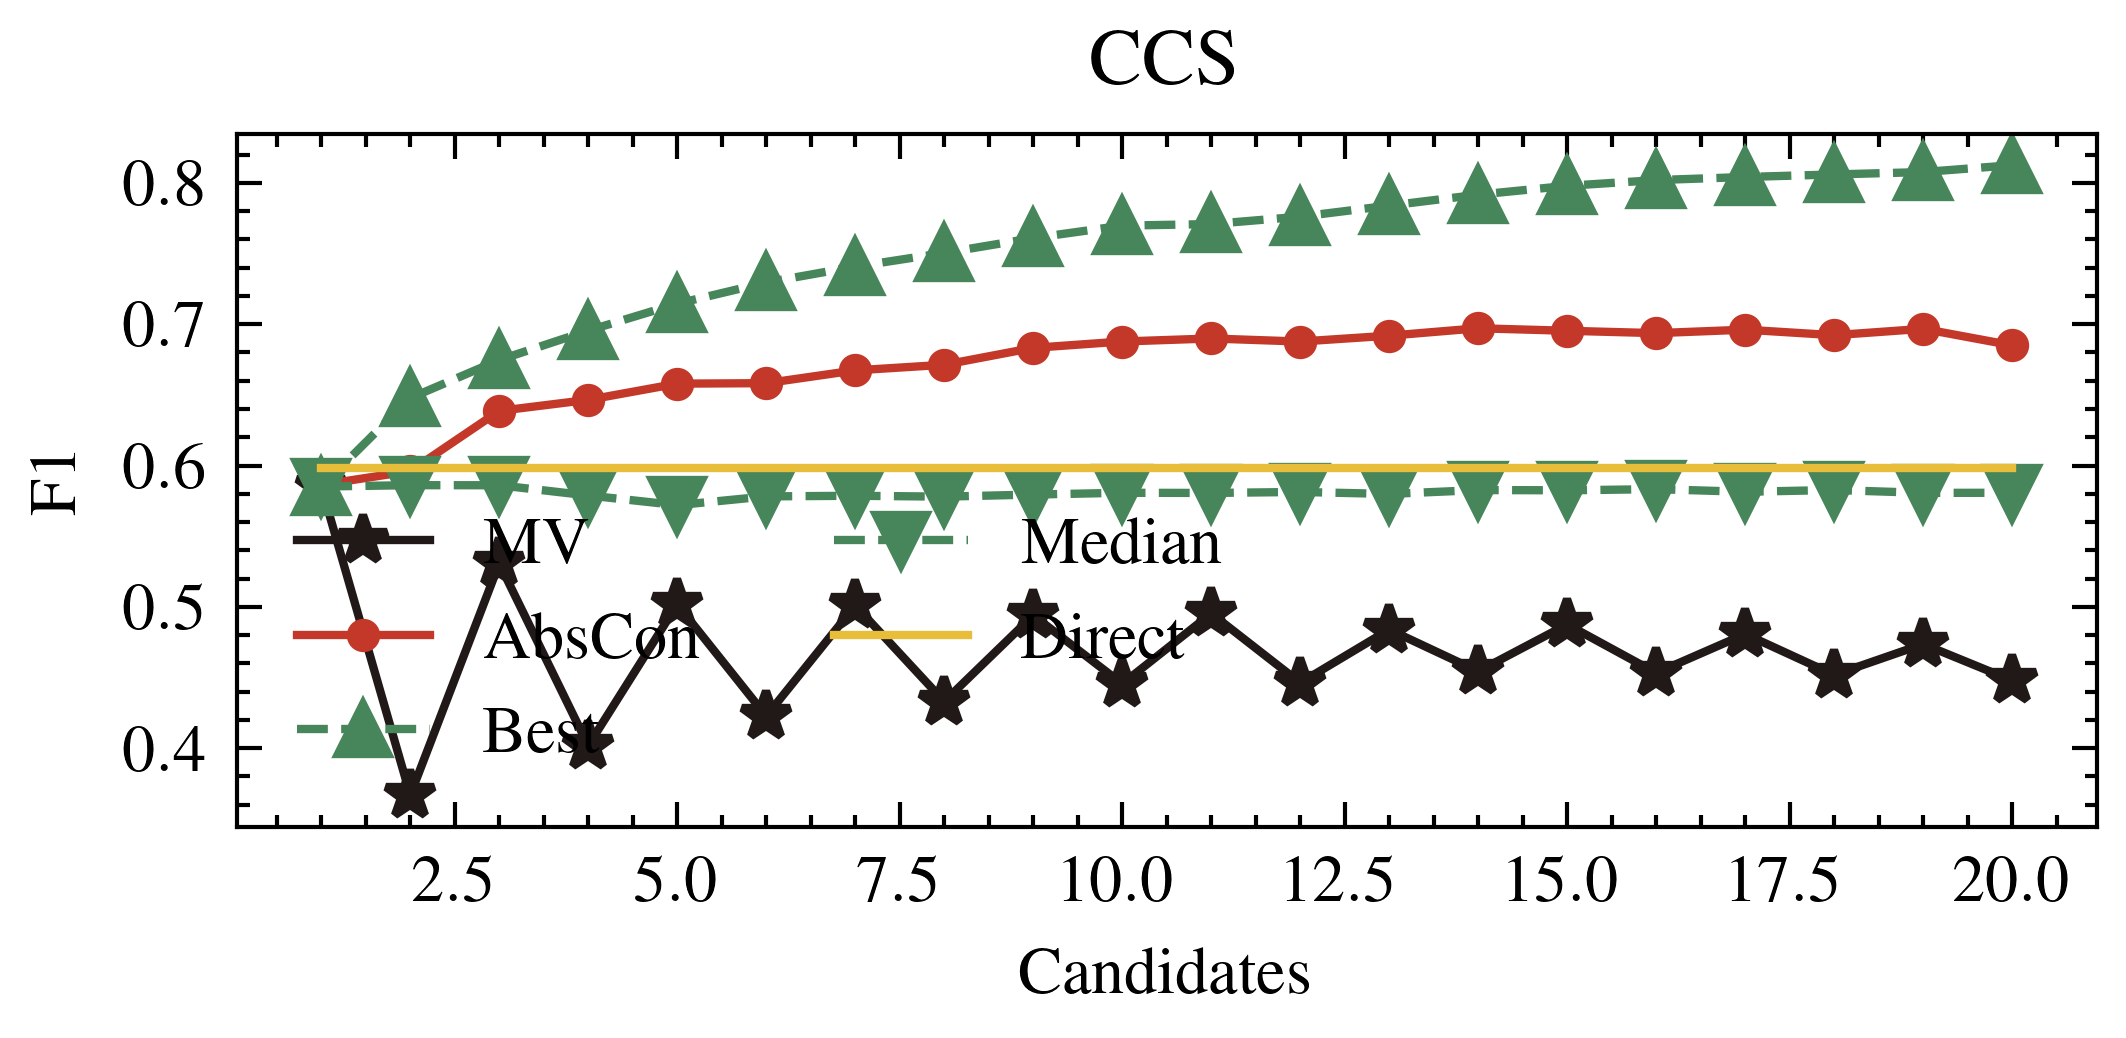

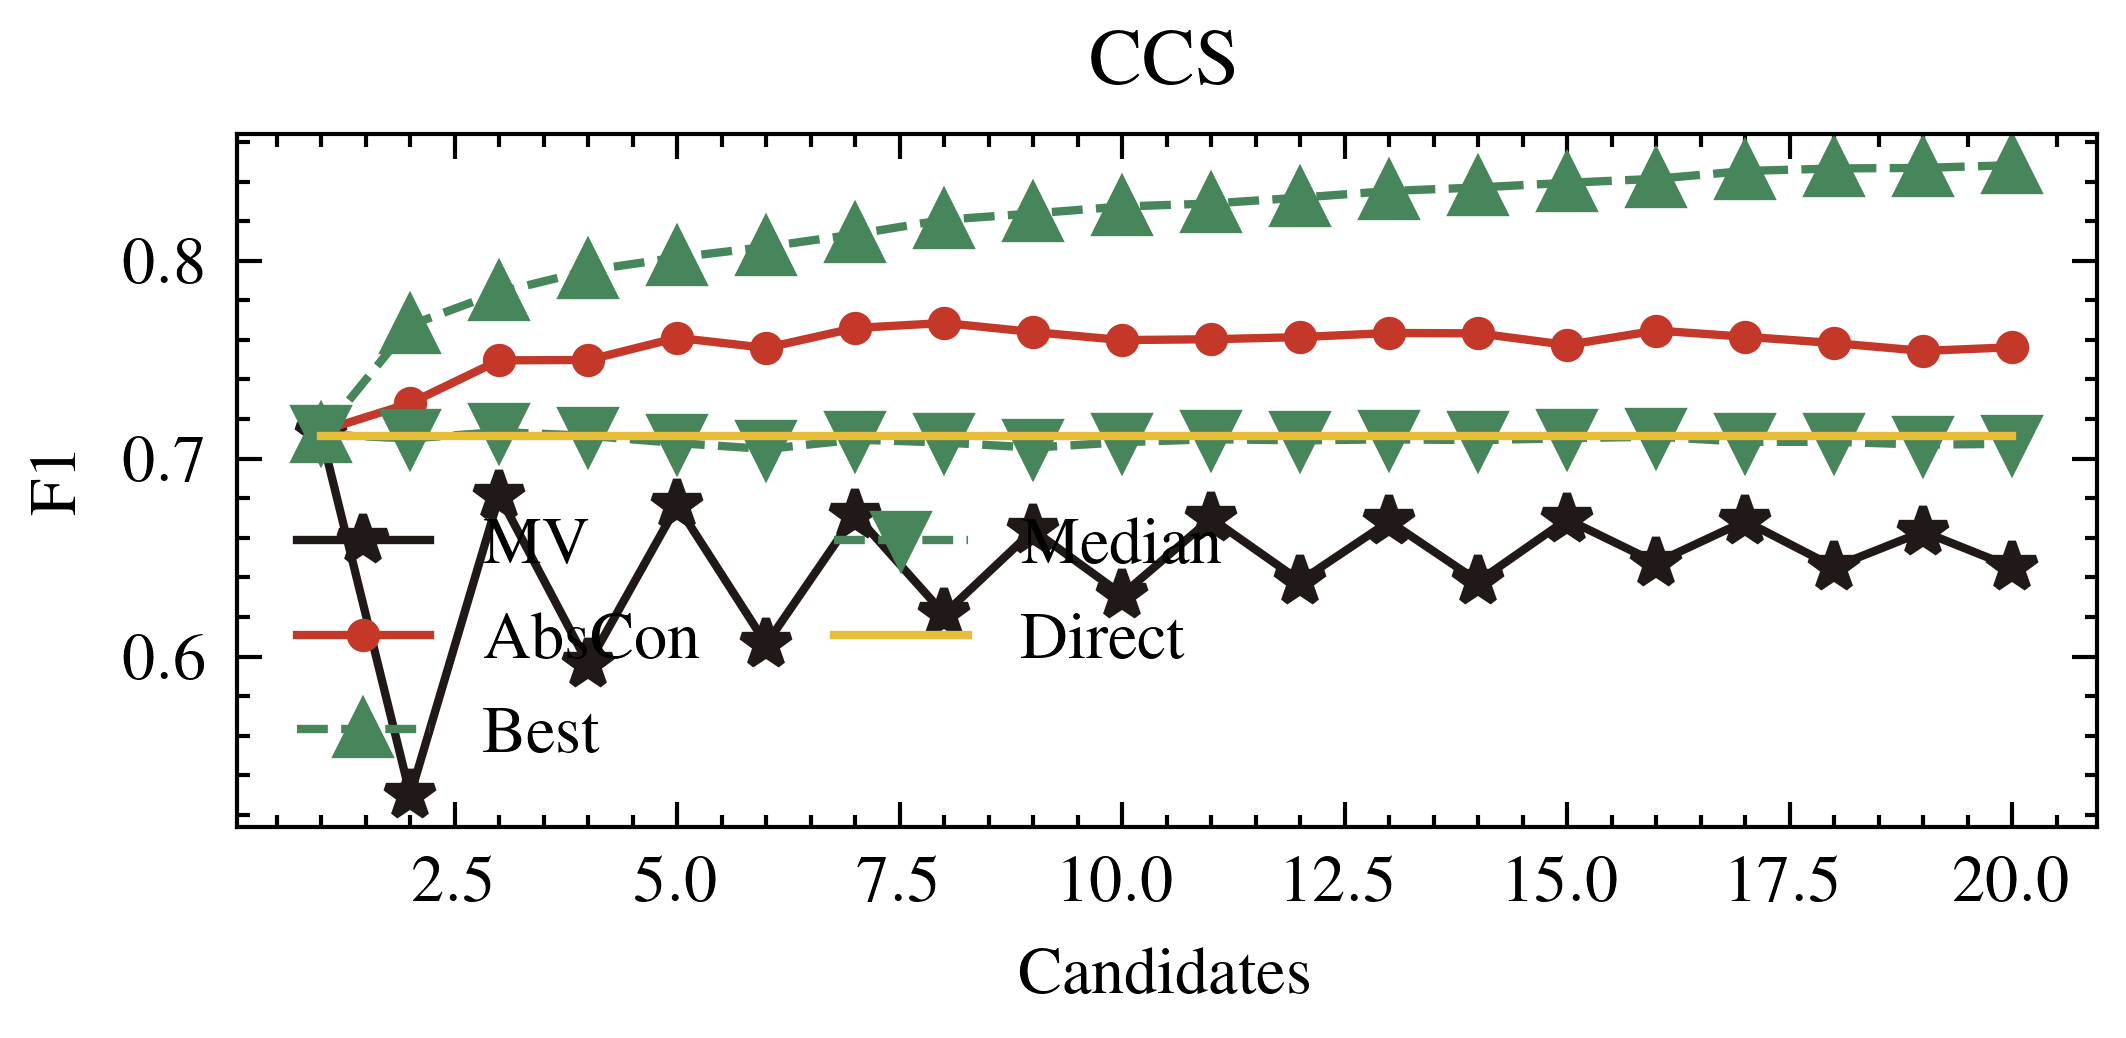

In [19]:
metric = "f1"
x = num_generations
f1_values = []
for i, llm in enumerate(models):
    plt.figure(figsize=(4,1.5))
    for j, approach in enumerate(approaches):
        values = [data[approach][llm][metric] for data in results]
        if approach in ["mv", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    plt.legend(shadow=True, ncol=2)
    plt.title("CCS")
    plt.ylabel("F1")
    plt.xlabel("Candidates")
    # plt.savefig("CCS.png", dpi=300)
    plt.show()        

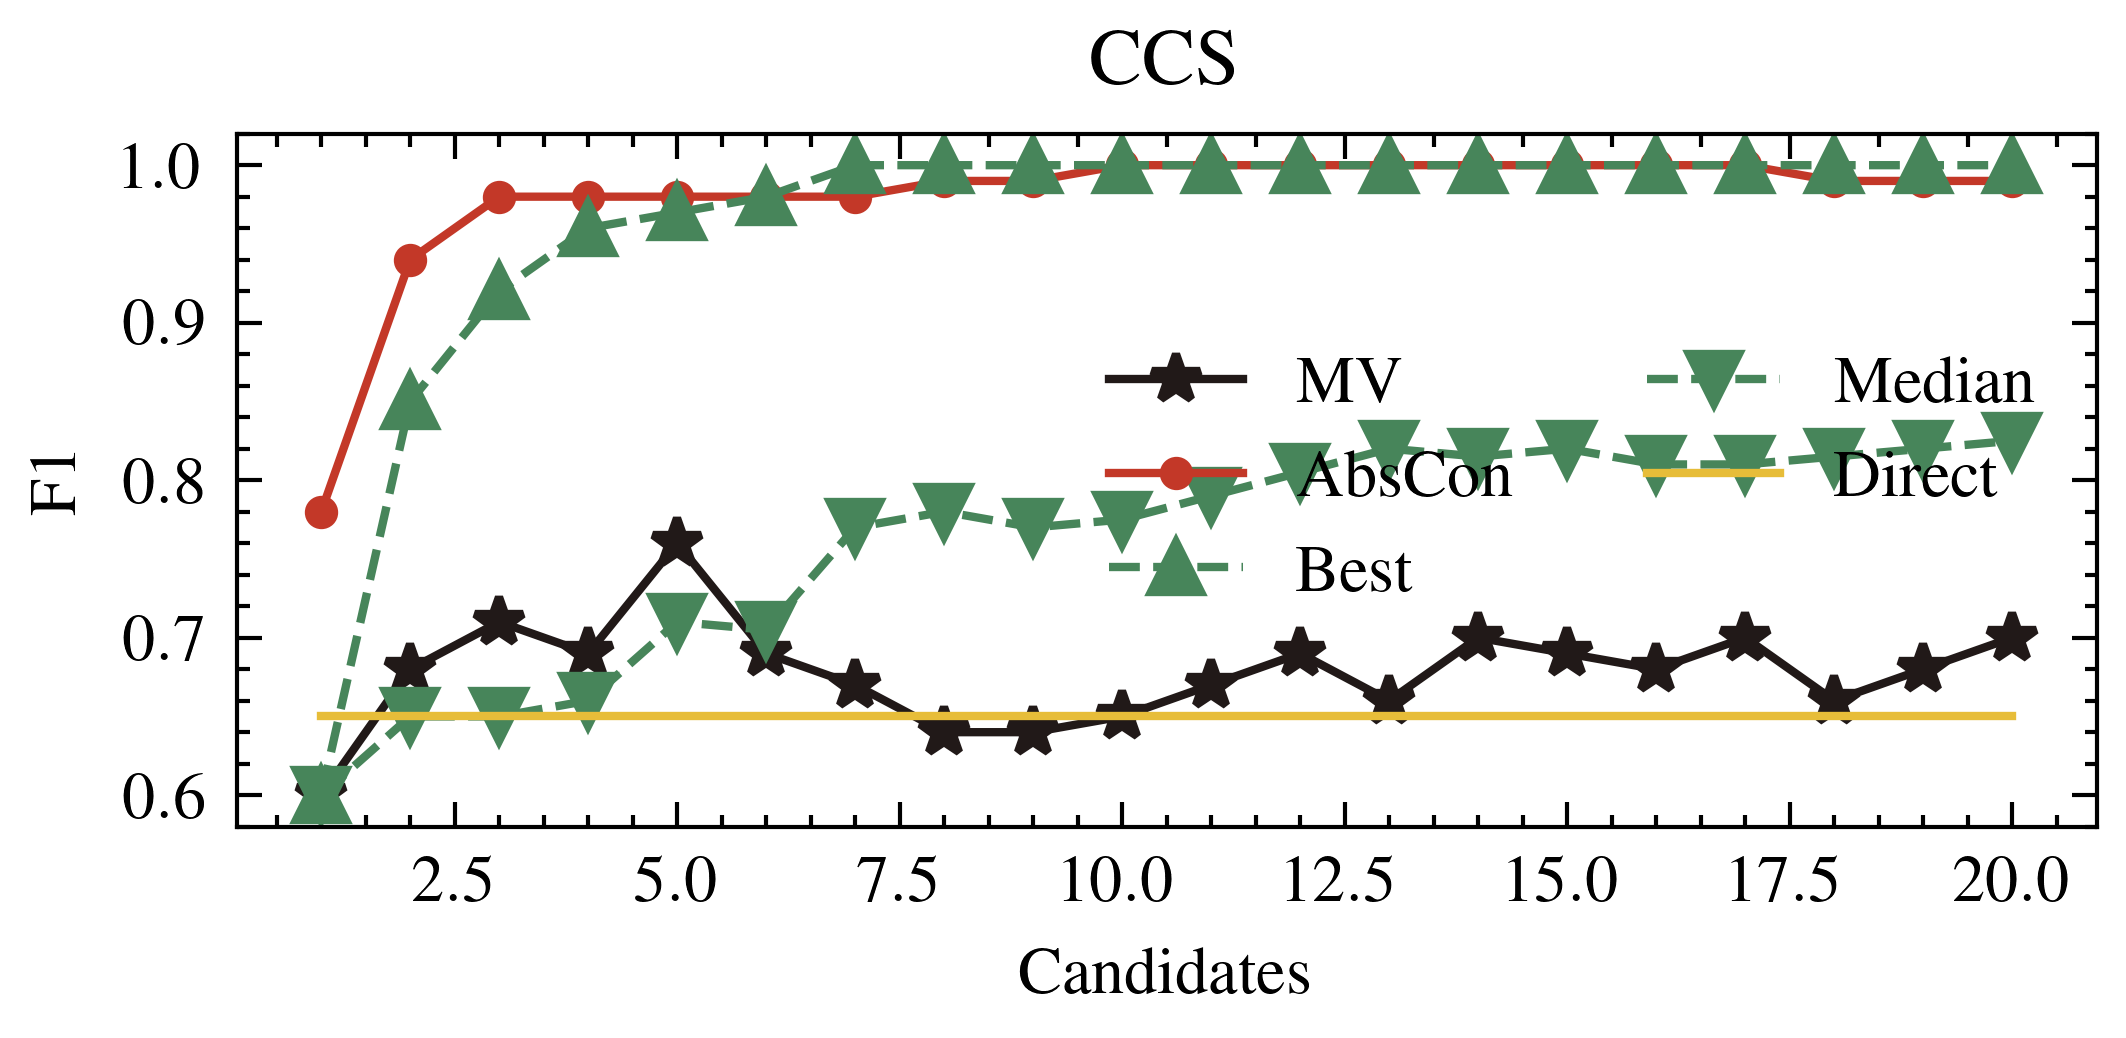

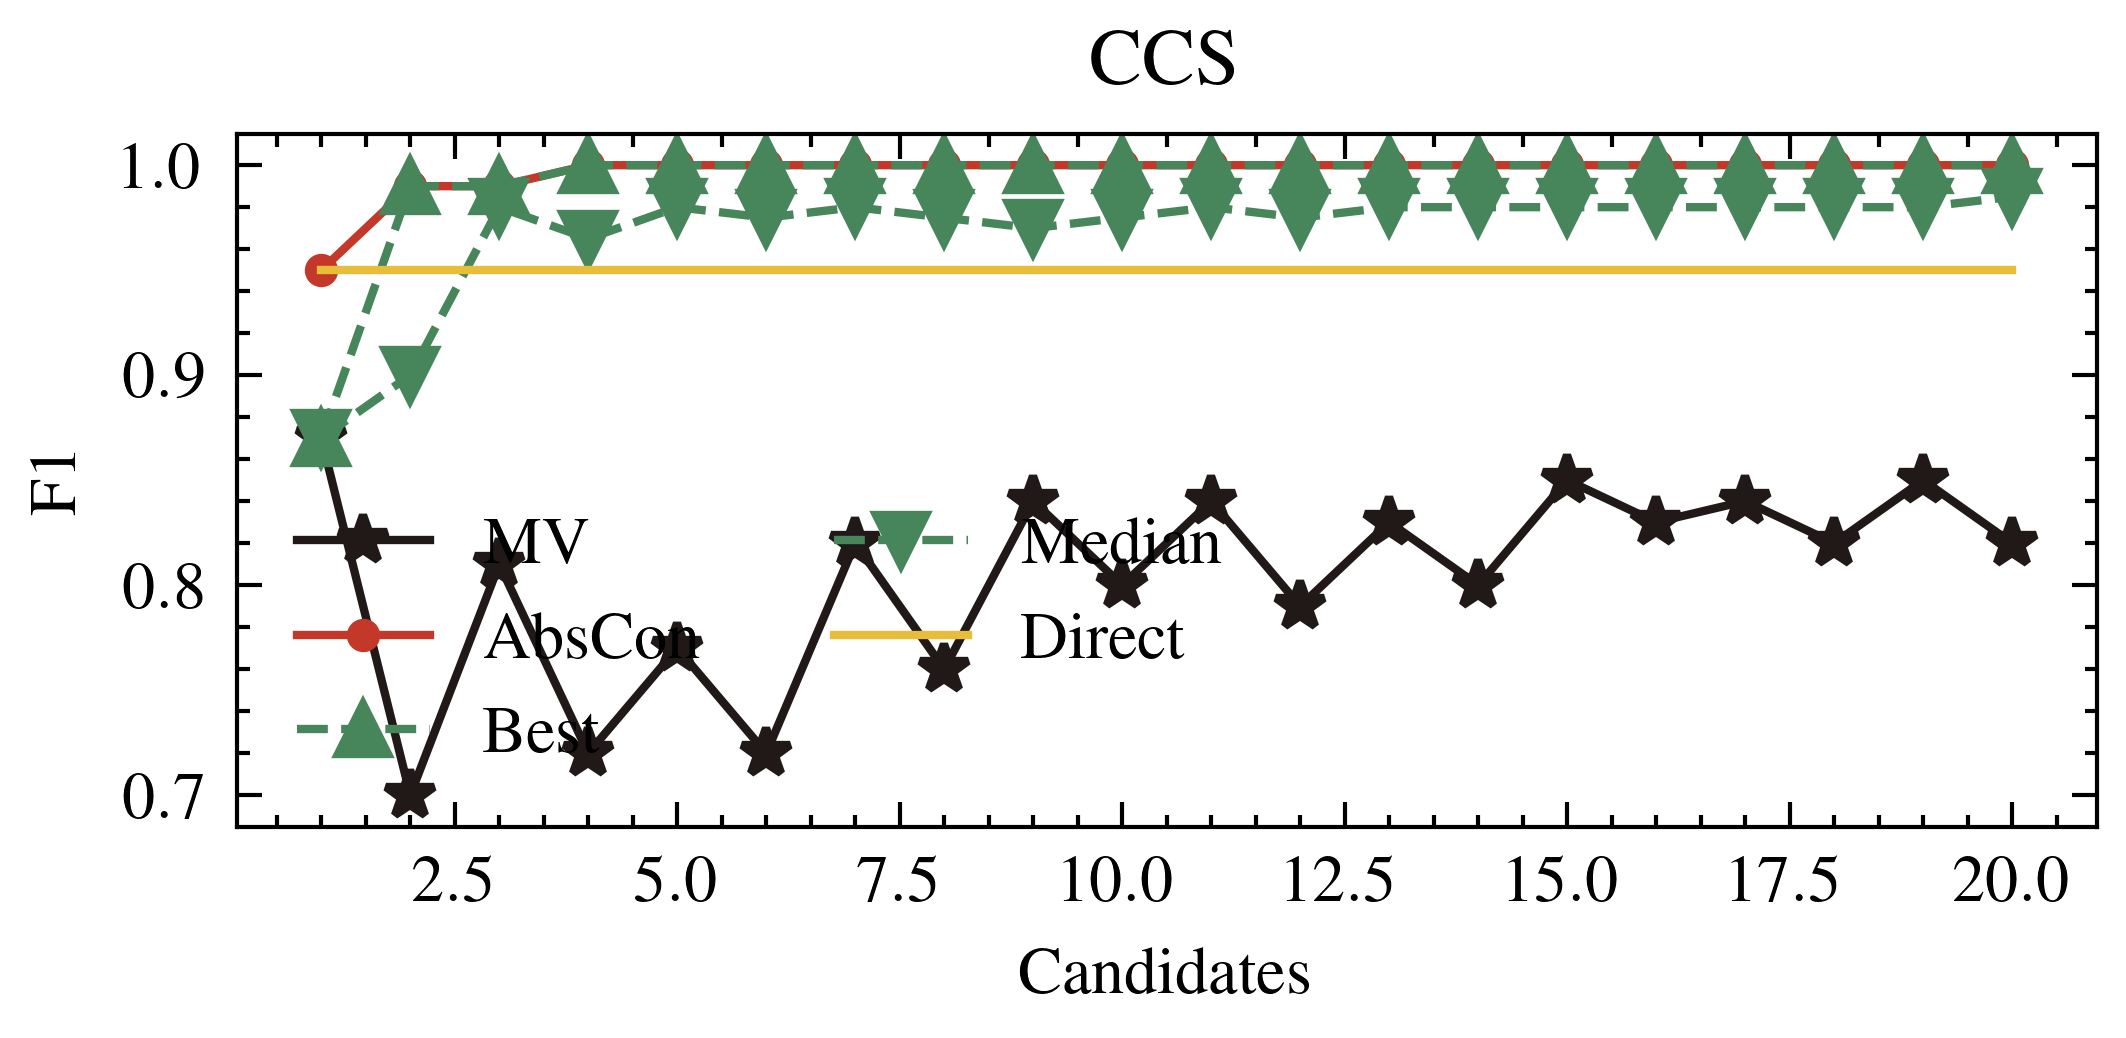

In [21]:
metric = "consistency"
x = num_generations
f1_values = []
for i, llm in enumerate(models):
    plt.figure(figsize=(4,1.5))
    for j, approach in enumerate(approaches):
        values = [data[approach][llm][metric] for data in results]
        if approach in ["mv", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    plt.legend(shadow=True, ncol=2)
    plt.title("CCS")
    plt.ylabel("F1")
    plt.xlabel("Candidates")
    # plt.savefig("CCS.png", dpi=300)
    plt.show()        

In [ ]:
from scipy.stats import spearmanr

spearmanr(f1_values, consistency_values, alternative="greater")

In [ ]:
from scipy.stats import spearmanr

spearmanr(f1_values, consistency_values, alternative="greater")

## RQ3: Impact of temperature

In [8]:
from tqdm.notebook import tqdm

In [9]:
def get_result_temperature(ground_truth_folder, dataset, llms, num_generation, temperatures, folder):
    ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"
    result = {}
    for temperature in temperatures:
        result[temperature] = {}
        for llm in llms:
            folder_path = f"{folder}/temperature/{temperature}/{llm}"
            evaluator = TaxonomyEvaluator(
                folder_path, dataset, ground_truth_path, num_generation
            )
            df = pd.read_csv(
                f"{folder_path}/{dataset}/results_abscon_{num_generation}.csv"
            )
            metrics = evaluator.evaluate_taxonomies(df, dataset)
            result[temperature][llm] = metrics

    return result

In [13]:
dataset = "wordnet"
ground_truth_folder = "data"
folder = "results"
temperatures = ["0.1", "0.4", "0.7", "1.0"]
num_generations = range(1, 11)
llms = ["llama-3.1-8b-instruct", "llama-3.1-70b-instruct"]

results = []

for num_generation in tqdm(num_generations):
    result = get_result_temperature(ground_truth_folder, dataset, llms, num_generation, temperatures, folder)
    results.append(result)

  0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib
plt.style.use(['science', "ieee"])

# models = ["llama_8b", "llama_70b", "gpt_4o_mini", "gpt_4o"]
models = ["llama-3.1-8b-instruct", "llama-3.1-70b-instruct"]
model_names = ["Llama3.1 8b", "Llama3.1 70b"]
metrics = ["f1", "consistency"]
temperatures = ["0.1", "0.4", "0.7", "1.0"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] ,  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

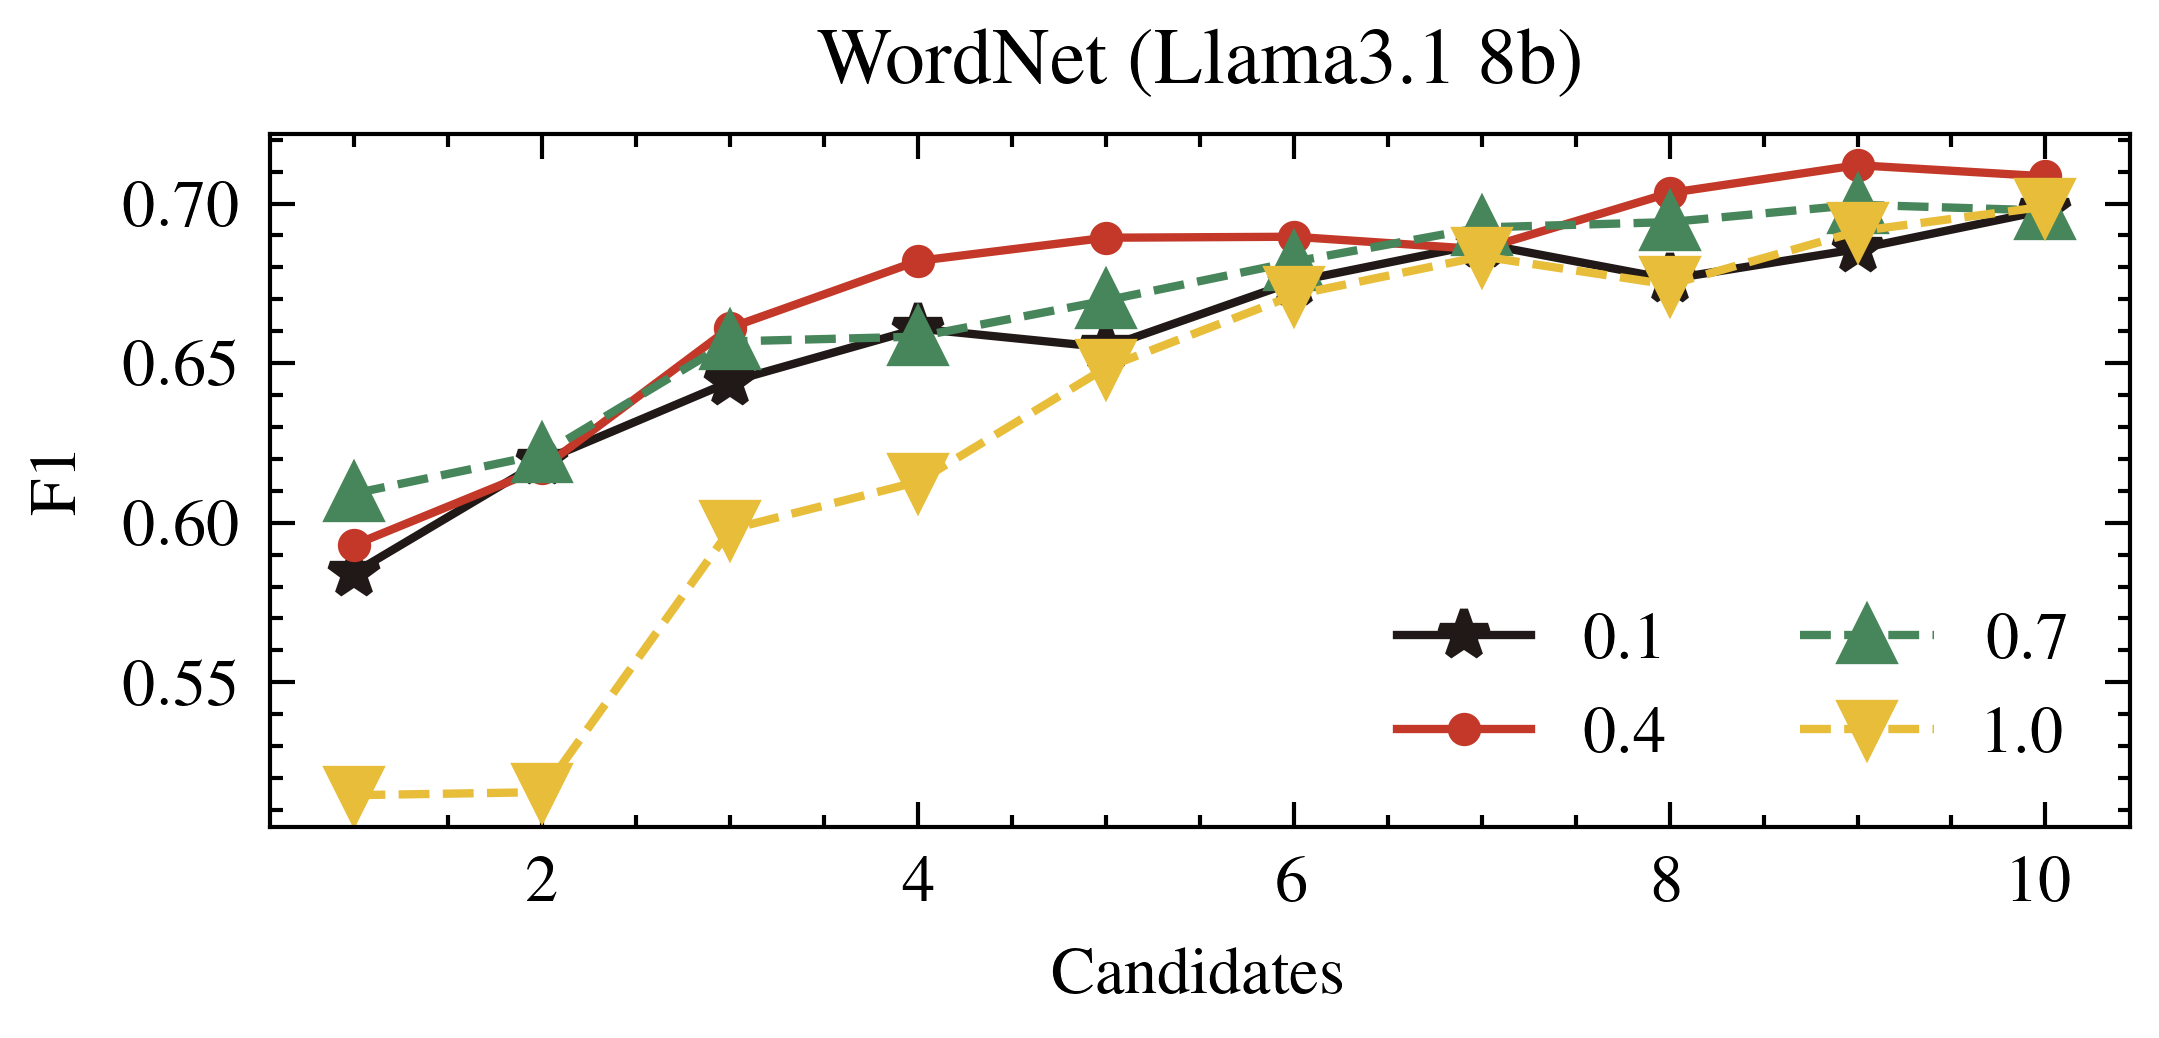

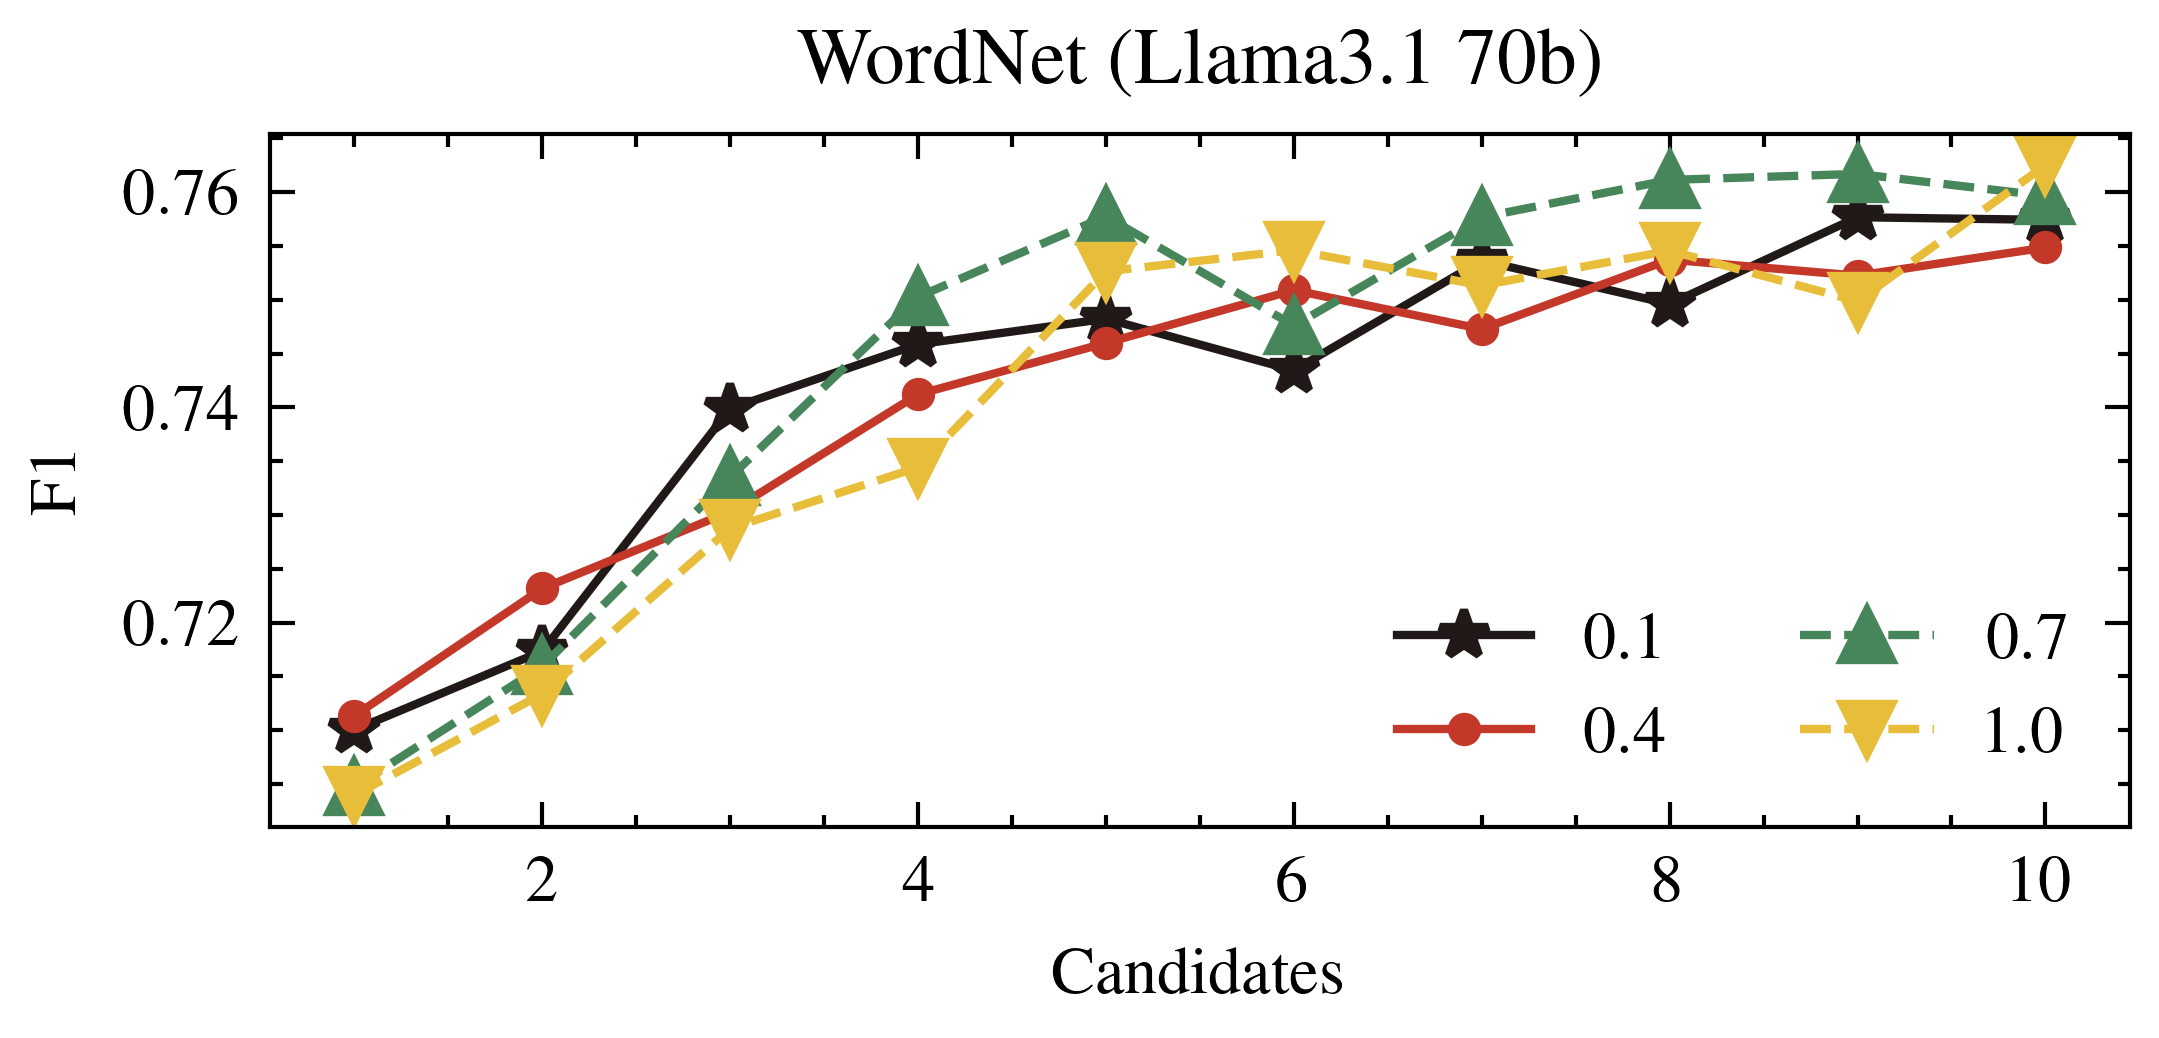

In [18]:
metric = "f1"
x = num_generations
f1_values = []
for i, llm in enumerate(models):
    plt.figure(figsize=(4,1.5))
    for j, temperature in enumerate(temperatures):
        values = [data[temperature][llm][metric] for data in results]
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=temperature, marker=markers[j])
    plt.legend(shadow=True, ncol=2)
    plt.title(f"WordNet ({model_names[i]})")
    plt.ylabel("F1")
    plt.xlabel("Candidates")
    # plt.savefig("CCS.png", dpi=300)
    plt.show()        

In [30]:
folder = "results"
ground_truth_folder = "data"
approaches = ["abscon", "mv"]
llms = ["llama-3.1-8b-instruct", "llama-3.1-70b-instruct"]

num_generation = 5

temperatures = ["0.1", "0.4", "0.7", "1.0"]

In [31]:
dataset = "wordnet"

temperature_results = {}

for temperature in temperatures:
    temperature_folder = f"{folder}/temperature/{temperature}"
    temperature_results[temperature] = get_result(
        ground_truth_folder, dataset, llms, num_generation, approaches, temperature_folder
    )
temperature_results = transform_results(temperature_results)

In [33]:
df = pd.DataFrame(temperature_results)
df[df.select_dtypes(include=["number"]).columns] *= 100
df = df[
    [
        "temperature",
        "f1_llama-3.1-8b-instruct",
        "consistency_llama-3.1-8b-instruct",
        "f1_llama-3.1-70b-instruct",
        "consistency_llama-3.1-70b-instruct",
    ]
]

print(df.round(2).to_markdown(index=False))

| temperature   |   f1_llama-3.1-8b-instruct |   consistency_llama-3.1-8b-instruct |   f1_llama-3.1-70b-instruct |   consistency_llama-3.1-70b-instruct |
|:--------------|---------------------------:|------------------------------------:|----------------------------:|-------------------------------------:|
| 0.1_abscon    |                      65.49 |                                 100 |                       74.82 |                                   99 |
| 0.1_mv        |                      52.13 |                                  63 |                       68.08 |                                   82 |
| 0.4_abscon    |                      68.93 |                                 100 |                       74.6  |                                   98 |
| 0.4_mv        |                      53.01 |                                  67 |                       67.96 |                                   84 |
| 0.7_abscon    |                      66.96 |                              

In [ ]:
dataset = "ccs"

temperature_results = {}

for temperature in temperatures:
    temperature_folder = f"{folder}/temperature/{temperature}"
    temperature_results[temperature] = get_result(
        ground_truth_folder, dataset, llms, num_generation, approaches, temperature_folder
    )
temperature_results = transform_results(temperature_results)

In [ ]:
df = pd.DataFrame(temperature_results)
df[df.select_dtypes(include=["number"]).columns] *= 100
df = df[
    [
        "temperature",
        "f1_Meta-Llama-3.1-70B-Instruct",
        "consistency_Meta-Llama-3.1-70B-Instruct",
        "f1_gpt-4o-mini",
        "consistency_gpt-4o-mini",
    ]
]

print(df.round(2).to_latex(index=False, header=False))

## Plot other figure

In [ ]:
x = range(1, 11)


def plot_metric(metric, row, col, index, results, type, legend=True, title=True):
    plt.subplot(row, col, index)
    for i, model in enumerate(models):
        plt.plot(
            x,
            [data[metric] for data in results[model]],
            lines[i],
            label=model_names[i],
            linewidth=2,
            # color=colors[i]
        )
        plt.xticks(x, [1,2,3,4,5,6,7,8,9,10]) 
        plt.annotate
    if legend:
        plt.legend()
    if title:
        plt.title(f"{metric.title()} v.s. Number of Candidates")

In [ ]:
font = {'family' : 'normal',
        'size'   : 12}

plt.rc('font', **font)

In [ ]:
plt.figure(figsize=(8,4.5))
plot_metric("consistency", 2, 2, 1, result_changes, "Constraints", legend=True)
plot_metric("f1", 2, 2, 2, result_changes, "Constraints", legend=False)
plot_metric("consistency", 2, 2, 3, result_changes_mv, "Majority Voting", legend=False, title=False)
plot_metric("f1", 2, 2, 4, result_changes_mv, "Majority Voting", legend=False, title=False)

plt.savefig("results.png", dpi=300)
plt.show()

In [ ]:
x = range(1, 6)

for metric in metrics:
    for model in models:
        plt.plot(x, [data[metric] for data in result_changes[model]], label=model)
    plt.legend()
    plt.title(f"{metric} change w.r.t. samples (constraint)")
    plt.show()


In [ ]:
x = range(1, 6)

for metric in metrics:
    for model in models:
        plt.plot(x, [data[metric] for data in result_changes_mv[model]])
    plt.title(f"{metric} change w.r.t. samples (voting)")
    plt.show()


## Evaluation of DeepSeek

In [ ]:
llm = "gpt-4o-mini/"
dataset = "wordnet"
folder = "results"
folder_path = f"{folder}/{llm}"
ground_truth_folder = "data"
ground_truth_path = f"{ground_truth_folder}/{dataset}.csv"
num_generation = 1

evaluator = TaxonomyEvaluator(
    folder_path,
    dataset,
    ground_truth_path,
    num_generation,
    evaluate_greedy=True,
)
metrics = evaluator.evaluate_abstraction(
    num_generation, concretization_method="mv", dataset=dataset
)